# 01 — Exploratory Data Analysis
Raw dataset: `data/raw/credit_risk.parquet` (1M rows, 202001–202604)

Covers:
- Shape, dtypes, missing values
- Target distribution and class imbalance
- Temporal distribution of records and default rate per period
- Numeric feature distributions (histograms + box plots)
- Correlation heatmap
- Train / Test / Monitor split sizes

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yaml

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

In [2]:
with open('../params.yaml') as f:
    params = yaml.safe_load(f)

DATA = params['data']
FEATURES = params['features']

TARGET = FEATURES['target']
PERIOD = FEATURES['period_col']
NUMERIC = FEATURES['numeric']
CATEGORICAL = FEATURES['categorical']

print(f"Train ≤ {DATA['train_end_periodo']}")
print(f"Test  {DATA['test_start_periodo']}–{DATA['test_end_periodo']}")
print(f"Monitor ≥ {DATA['monitor_start_periodo']}")

Train ≤ 202312
Test  202401–202512
Monitor ≥ 202601


## 1. Load dataset

In [3]:
df = pd.read_parquet(f"../{DATA['raw_path']}")
print(f"Shape: {df.shape}")
df.head()

Shape: (1000000, 15)


,periodo,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,loan_amount,employment_years,credit_score_band
0,202410,0,0.218946,65,0,3.160331,850.080017,16,0,2,0,7.0,25710.710938,2.240785,Poor
1,202102,0,0.175514,27,1,0.853028,832.899231,5,0,2,0,7.0,47281.304688,8.251482,Very Good
2,202206,0,0.463530,89,0,0.838946,4691.684082,11,0,4,0,0.0,30580.822266,4.110099,Good
3,202201,0,0.701757,79,1,1.340224,NaN,5,1,4,0,3.0,31975.355469,0.078221,Very Good
4,202603,0,0.330305,81,0,0.215290,5767.911133,3,0,4,0,0.0,22358.865234,14.160415,Poor


In [4]:
df.dtypes.to_frame('dtype').assign(
    null_count=df.isnull().sum(),
    null_pct=(df.isnull().mean() * 100).round(2)
)

,dtype,null_count,null_pct
periodo,int64,0,0.00
SeriousDlqin2yrs,int8,0,0.00
RevolvingUtilizationOfUnsecuredLines,float32,0,0.00
age,int16,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,int16,0,0.00
DebtRatio,float32,0,0.00
MonthlyIncome,float32,20025,2.00
NumberOfOpenCreditLinesAndLoans,int16,0,0.00
NumberOfTimes90DaysLate,int16,0,0.00
NumberRealEstateLoansOrLines,int16,0,0.00


## 2. Target — class imbalance

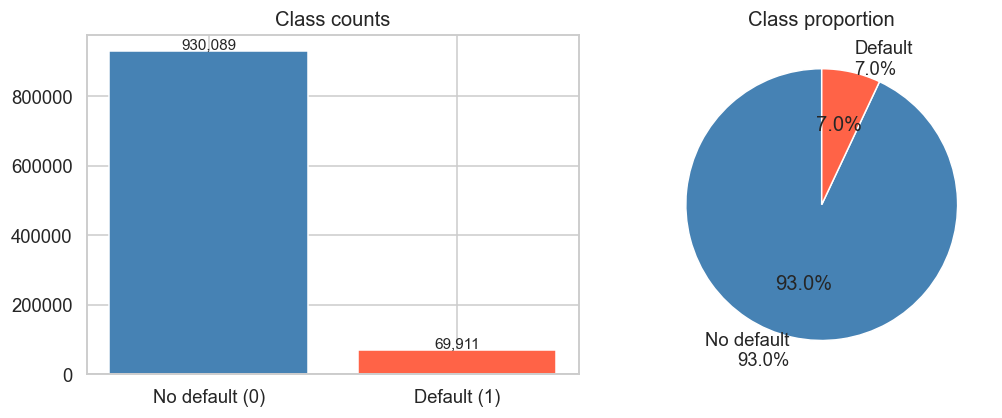

Default rate: 0.0699


In [5]:
counts = df[TARGET].value_counts()
pct = df[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['No default (0)', 'Default (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class counts')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(pct.values, labels=[f'No default\n{pct[0]:.1f}%', f'Default\n{pct[1]:.1f}%'],
            colors=['steelblue', 'tomato'], startangle=90, autopct='%1.1f%%')
axes[1].set_title('Class proportion')

plt.tight_layout()
plt.show()
print(f"Default rate: {df[TARGET].mean():.4f}")

## 3. Temporal distribution

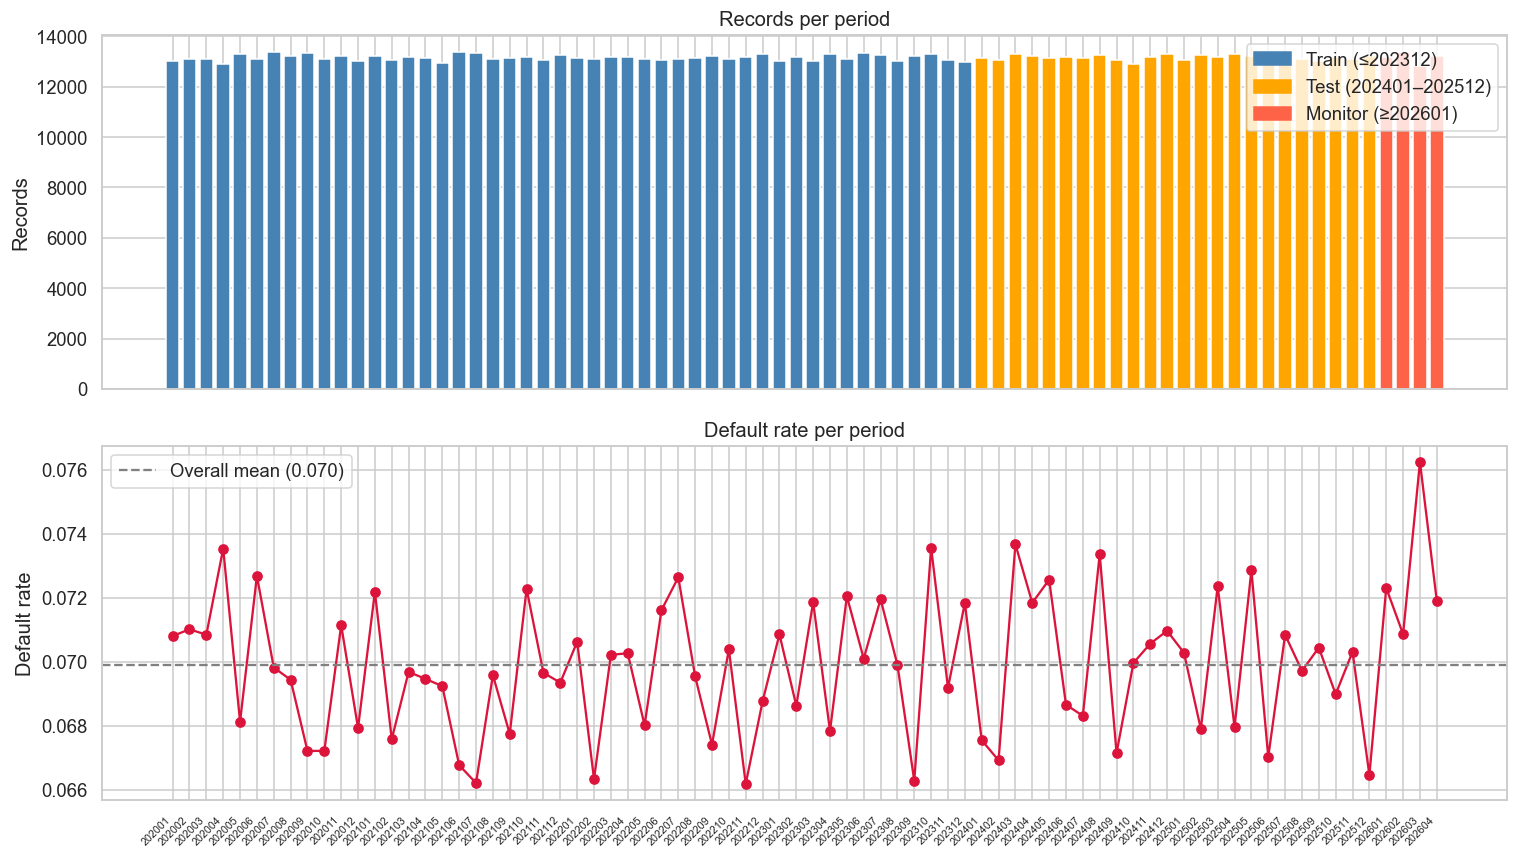

In [6]:
temporal = df.groupby(PERIOD).agg(
    records=(TARGET, 'count'),
    default_rate=(TARGET, 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# records per period
colors = ['steelblue' if p <= DATA['train_end_periodo']
          else ('orange' if p <= DATA['test_end_periodo'] else 'tomato')
          for p in temporal[PERIOD]]
axes[0].bar(temporal[PERIOD].astype(str), temporal['records'], color=colors, width=0.8)
axes[0].set_ylabel('Records')
axes[0].set_title('Records per period')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='steelblue', label='Train (≤202312)'),
    Patch(color='orange', label='Test (202401–202512)'),
    Patch(color='tomato', label='Monitor (≥202601)'),
])

# default rate per period
axes[1].plot(temporal[PERIOD].astype(str), temporal['default_rate'], marker='o', color='crimson', linewidth=1.5)
axes[1].axhline(df[TARGET].mean(), color='gray', linestyle='--', label=f'Overall mean ({df[TARGET].mean():.3f})')
axes[1].set_ylabel('Default rate')
axes[1].set_title('Default rate per period')
axes[1].legend()

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

## 4. Numeric feature distributions

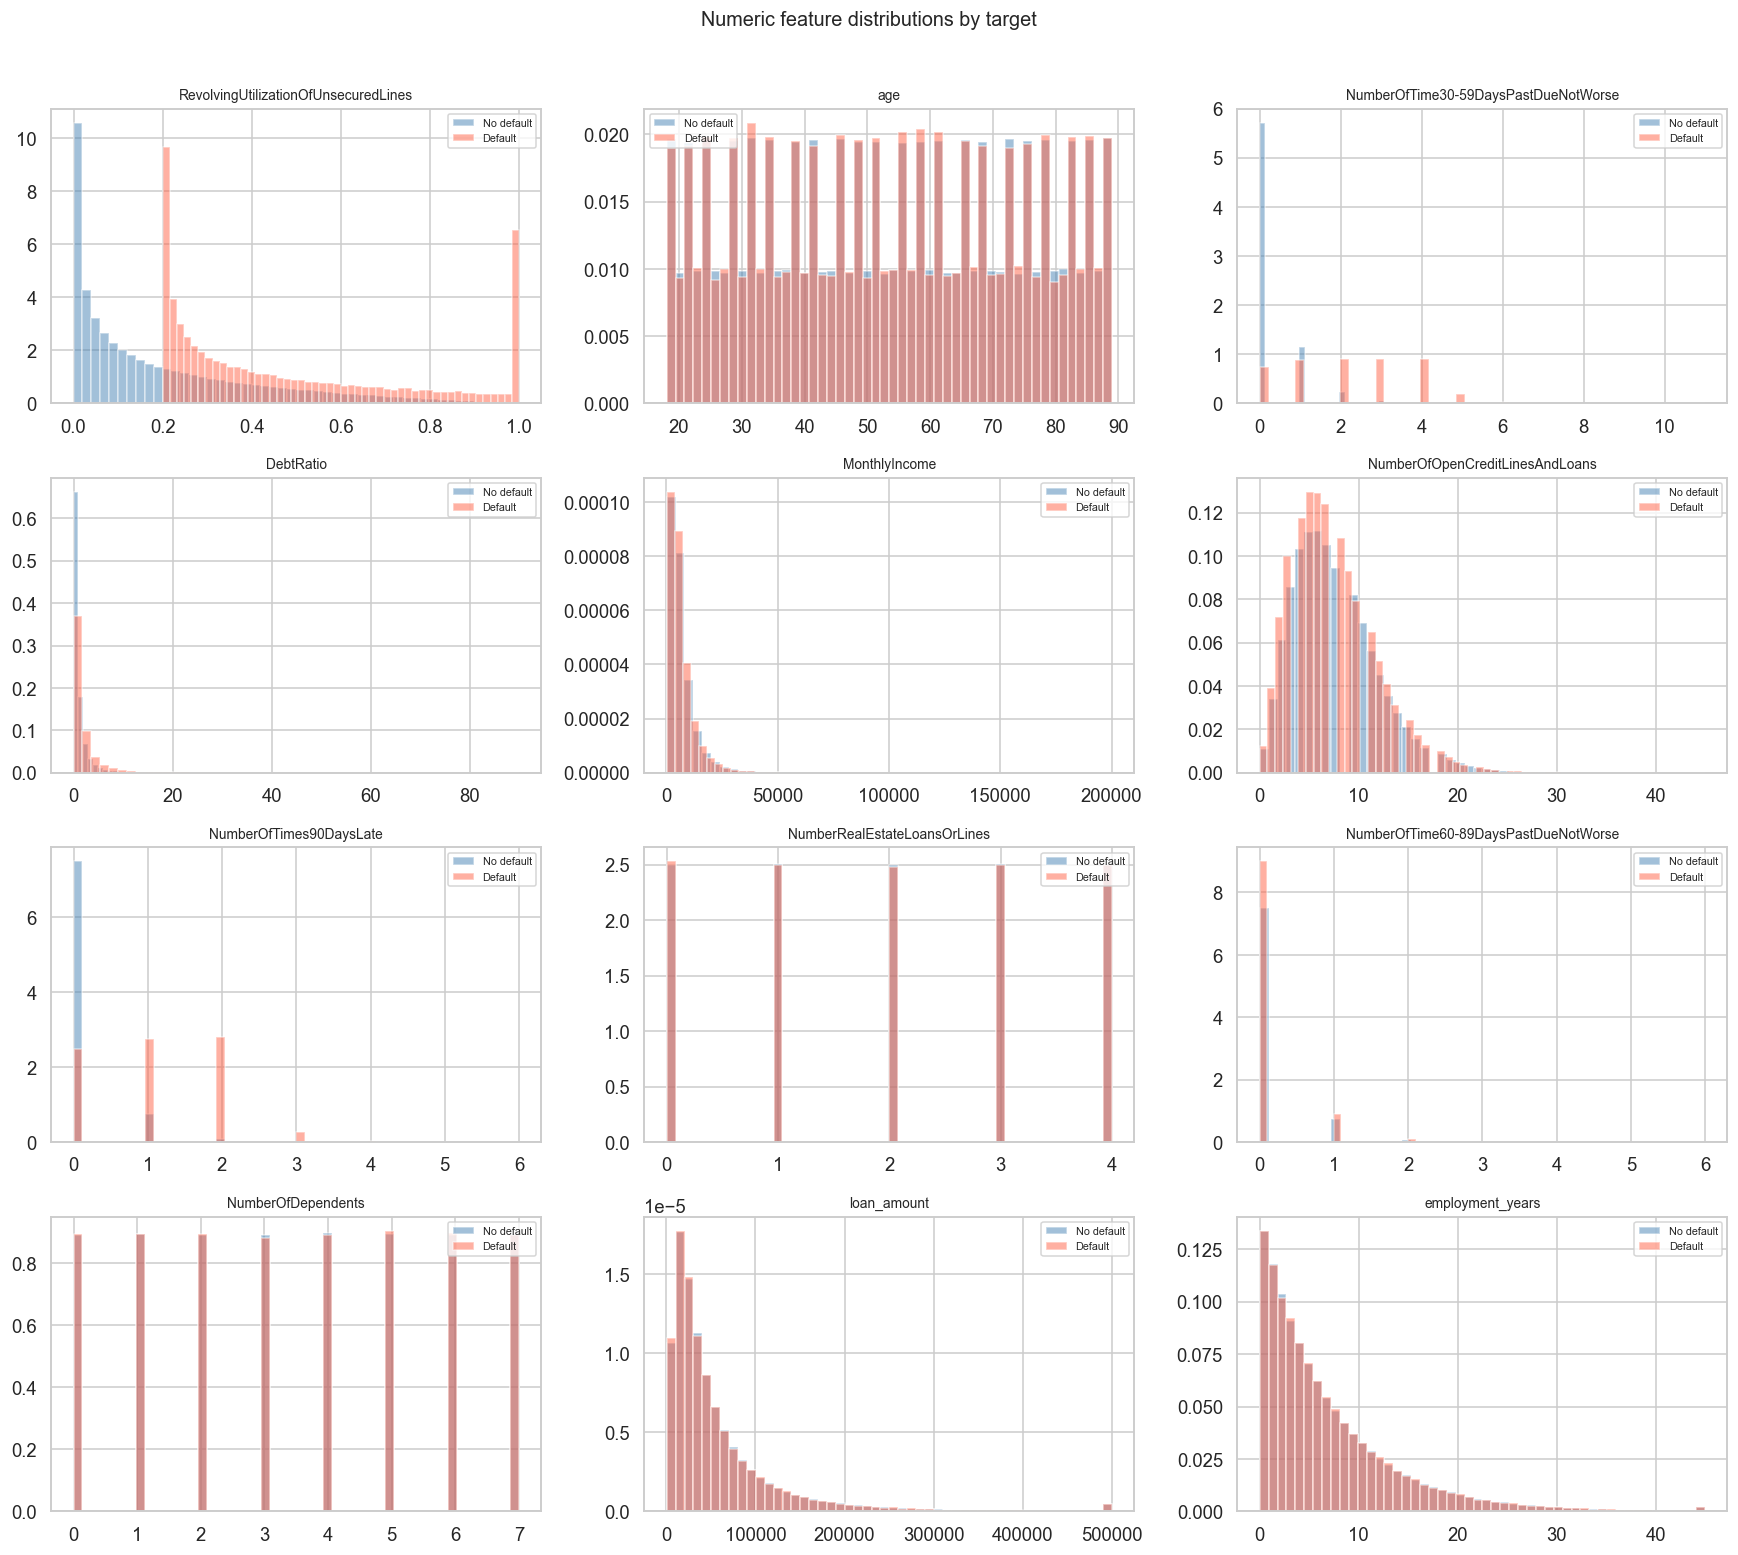

In [7]:
n_cols = 3
n_rows = int(np.ceil(len(NUMERIC) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(NUMERIC):
    data_no = df.loc[df[TARGET] == 0, col].dropna()
    data_yes = df.loc[df[TARGET] == 1, col].dropna()
    axes[i].hist(data_no, bins=50, alpha=0.5, label='No default', color='steelblue', density=True)
    axes[i].hist(data_yes, bins=50, alpha=0.5, label='Default', color='tomato', density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric feature distributions by target', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Missing values heatmap

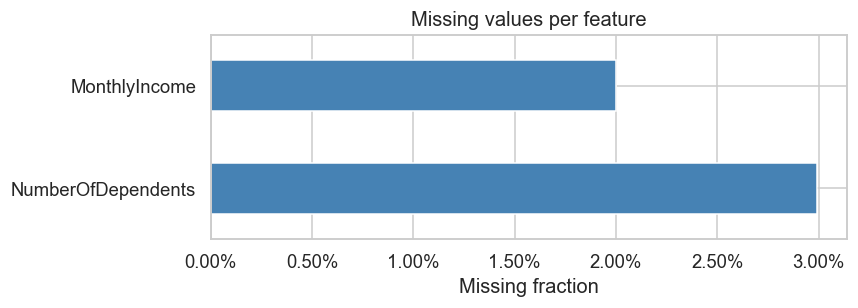

In [8]:
missing = df[NUMERIC + CATEGORICAL].isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(8, 3))
    missing.plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('Missing fraction')
    ax.set_title('Missing values per feature')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    plt.show()
else:
    print('No missing values in features.')

## 6. Correlation matrix

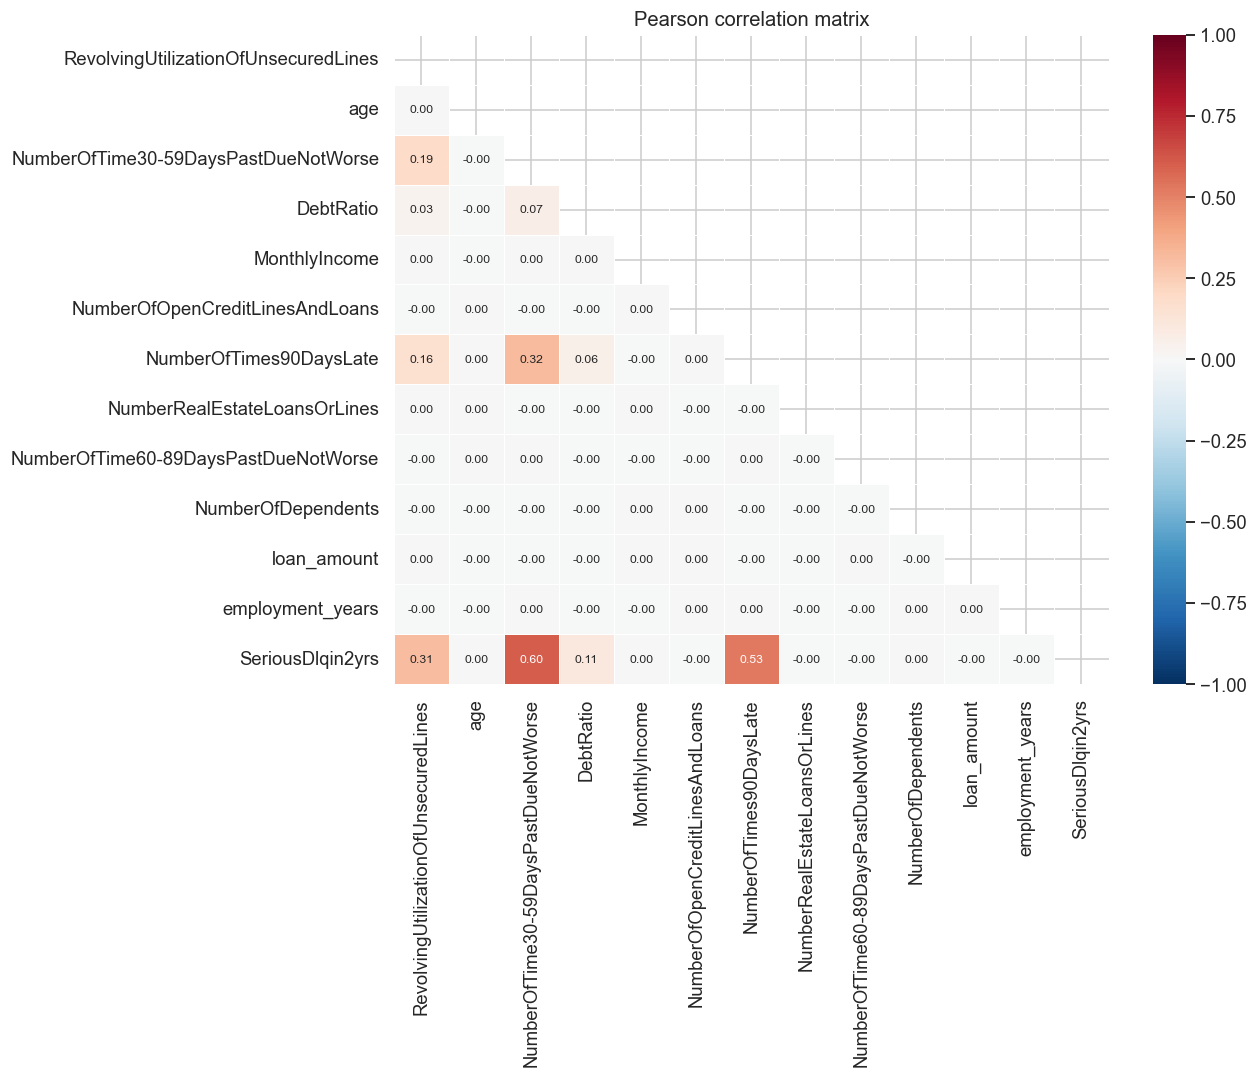

In [9]:
corr = df[NUMERIC + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Pearson correlation matrix')
plt.tight_layout()
plt.show()

## 7. Split summary

In [10]:
train_mask  = df[PERIOD] <= DATA['train_end_periodo']
test_mask   = (df[PERIOD] >= DATA['test_start_periodo']) & (df[PERIOD] <= DATA['test_end_periodo'])
monitor_mask = df[PERIOD] >= DATA['monitor_start_periodo']

summary = pd.DataFrame({
    'Split': ['Train', 'Test', 'Monitor'],
    'Periodo range': [
        f"202001–{DATA['train_end_periodo']}",
        f"{DATA['test_start_periodo']}–{DATA['test_end_periodo']}",
        f"{DATA['monitor_start_periodo']}–202604",
    ],
    'Rows': [train_mask.sum(), test_mask.sum(), monitor_mask.sum()],
    'Default rate': [
        df.loc[train_mask, TARGET].mean(),
        df.loc[test_mask, TARGET].mean(),
        df.loc[monitor_mask, TARGET].mean(),
    ],
})
summary['Rows'] = summary['Rows'].map('{:,}'.format)
summary['Default rate'] = summary['Default rate'].map('{:.4f}'.format)
summary

,Split,Periodo range,Rows,Default rate
0,Train,202001–202312,"631,361",0.0697
1,Test,202401–202512,"316,067",0.0699
2,Monitor,202601–202604,"52,572",0.0728


## 8. Categorical feature — credit_score_band

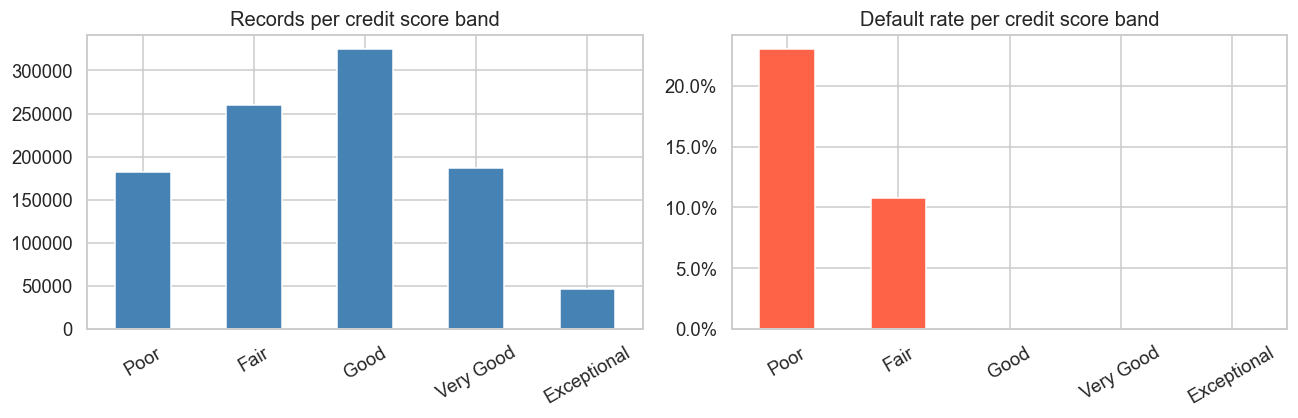

In [11]:
order = ['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']
band_stats = df.groupby('credit_score_band')[TARGET].agg(['count', 'mean']).reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
band_stats['count'].plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Records per credit score band')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

band_stats['mean'].plot.bar(ax=axes[1], color='tomato')
axes[1].set_title('Default rate per credit score band')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()